<a href="https://colab.research.google.com/github/Orlando090/DESAFIO-ALURA-STORE/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
# Primero calculamos la facturación total en cada tienda:

# Total vendido tienda 1
facturacion_tienda_1 = tienda['Precio'].sum()
print("\nFacturación total de la tienda 1:")
print(f"${facturacion_tienda_1:,.2f}")

# Total vendido tienda 2
facturacion_tienda_2 = tienda2['Precio'].sum()
print("\nFacturación total de la tienda 2:")
print(f"${facturacion_tienda_2:,.2f}")

# Total vendido tienda 3
facturacion_tienda_3 = tienda3['Precio'].sum()
print("\nFacturación total de la tienda 3:")
print(f"${facturacion_tienda_3:,.2f}")

# Total vendido tienda 4
facturacion_tienda_4 = tienda4['Precio'].sum()
print("\nFacturación total de la tienda 4:")
print(f"${facturacion_tienda_4:,.2f}")



Facturación total de la tienda 1:
$1,150,880,400.00

Facturación total de la tienda 2:
$1,116,343,500.00

Facturación total de la tienda 3:
$1,098,019,600.00

Facturación total de la tienda 4:
$1,038,375,700.00


In [3]:
#Ahora compararemos los valores y veremos cual tienda facturó la menor cantidad:

# Empesamos suponiendo que la tienda 1 es la que menos facturó al principio
menor_facturacion = facturacion_tienda_1
tienda_menor = "Tienda 1"

# Comparamos con las demás
if facturacion_tienda_2 < menor_facturacion:
    menor_facturacion = facturacion_tienda_2
    tienda_menor = "Tienda 2"
if facturacion_tienda_3 < menor_facturacion:
    menor_facturacion = facturacion_tienda_3
    tienda_menor = "Tienda 3"
if facturacion_tienda_4 < menor_facturacion:
    menor_facturacion = facturacion_tienda_4
    tienda_menor = "Tienda 4"

# Mostrar el resultado
print(f"La tienda que menos facturó fue {tienda_menor} con un total de: ${menor_facturacion:,.2f}")


La tienda que menos facturó fue Tienda 4 con un total de: $1,038,375,700.00


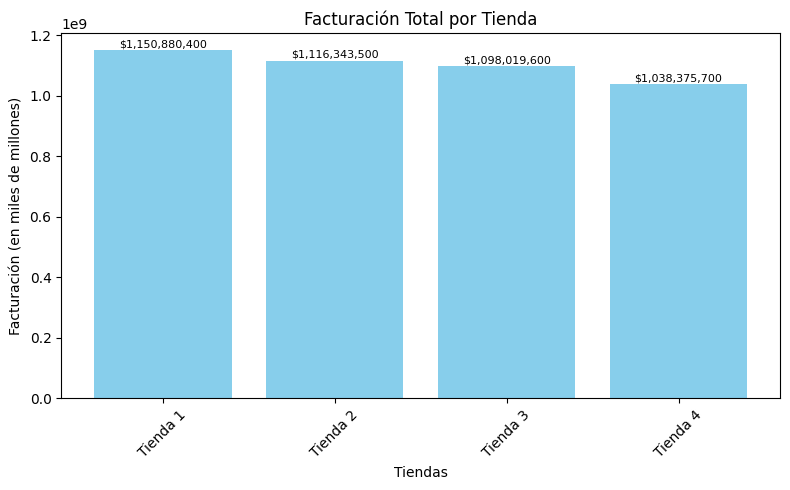

In [4]:
import matplotlib.pyplot as plt

# Nombres de las tiendas
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Facturación total de cada tienda
facturacion = [1150880400, 1116343500, 1098019600, 1038375700]

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))  # Tamaño del gráfico
plt.bar(tiendas, facturacion, color='skyblue')

# Título y etiquetas
plt.title('Facturación Total por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Facturación (en miles de millones)')
plt.xticks(rotation=45)

# Mostrar el valor encima de cada barra
for i, valor in enumerate(facturacion):
    plt.text(i, valor + 10000000, f"${valor:,.0f}", ha='center', fontsize=8)

# Mostrar el gráfico
plt.tight_layout()
plt.show()



# 2. Ventas por categoría

In [ ]:
import pandas as pd

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

# Agregamos una columna a cada tienda con su nombre
tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# Unimos todos los datos en una sola tabla
todas_las_tiendas = pd.concat([tienda, tienda2, tienda3, tienda4])

# Agrupar por Tienda y Categoría y contar las ventas y agregamos una columna cantidad
ventas_por_categoria = todas_las_tiendas.groupby(["Tienda", "Categoría del Producto"]).size().reset_index(name="Cantidad")

# Ordenar los resultados para ver las categorías más vendidas primero en cada tienda
ventas_ordenadas = ventas_por_categoria.sort_values(by=["Tienda", "Cantidad"], ascending=[True, False])

# Mostrar resultados
print(ventas_ordenadas)


      Tienda   Categoría del Producto  Cantidad
7   Tienda 1                  Muebles       465
3   Tienda 1             Electrónicos       448
5   Tienda 1                 Juguetes       324
2   Tienda 1        Electrodomésticos       312
1   Tienda 1     Deportes y diversión       284
4   Tienda 1   Instrumentos musicales       182
6   Tienda 1                   Libros       173
0   Tienda 1  Artículos para el hogar       171
15  Tienda 2                  Muebles       442
11  Tienda 2             Electrónicos       422
13  Tienda 2                 Juguetes       313
10  Tienda 2        Electrodomésticos       305
9   Tienda 2     Deportes y diversión       275
12  Tienda 2   Instrumentos musicales       224
14  Tienda 2                   Libros       197
8   Tienda 2  Artículos para el hogar       181
23  Tienda 3                  Muebles       499
19  Tienda 3             Electrónicos       451
21  Tienda 3                 Juguetes       315
18  Tienda 3        Electrodomésticos   

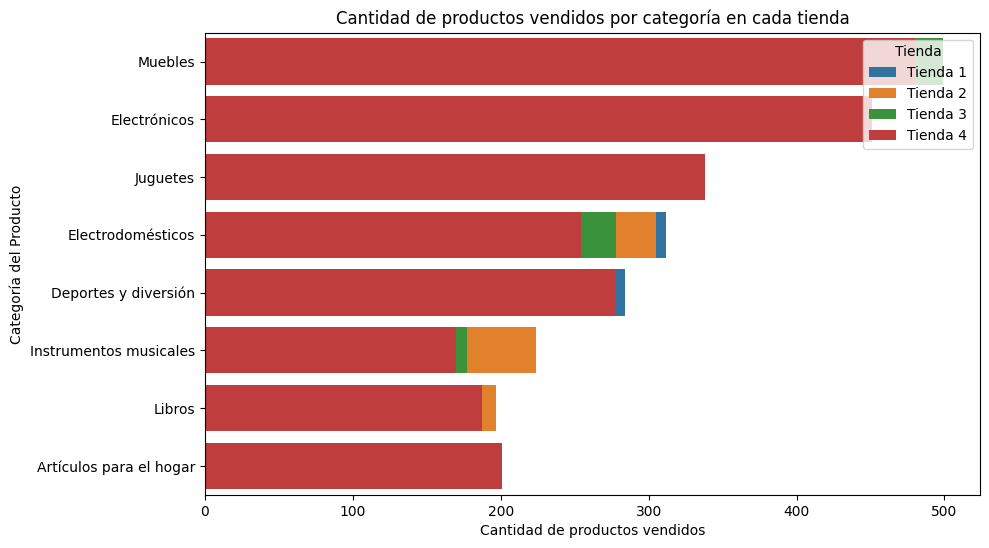

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 5: Graficar los resultados
plt.figure(figsize=(10, 6))  # Tamaño del gráfico
sns.barplot(data=ventas_ordenadas, x="Cantidad", y="Categoría del Producto", hue="Tienda", dodge=False)

# Personalizar el gráfico
plt.title("Cantidad de productos vendidos por categoría en cada tienda")
plt.xlabel("Cantidad de productos vendidos")
plt.ylabel("Categoría del Producto")
plt.legend(title="Tienda", loc="upper right")

# Mostrar el gráfico
plt.show()


# 3. Calificación promedio de la tienda


In [ ]:

# Paso 2: Unimos todos los datos en un solo DataFrame
todas_las_tiendas = pd.concat([tienda, tienda2, tienda3, tienda4])

# Paso 3: Calculamos el promedio de calificación por tienda
promedios = todas_las_tiendas.groupby("Tienda")["Calificación"].mean().round(2).reset_index()

# Paso 4: Renombramos la columna para mayor claridad
promedios.columns = ["Tienda", "Calificación Promedio"]

# Mostramos los resultados
print(promedios)


     Tienda  Calificación Promedio
0  Tienda 1                   3.98
1  Tienda 2                   4.04
2  Tienda 3                   4.05
3  Tienda 4                   4.00


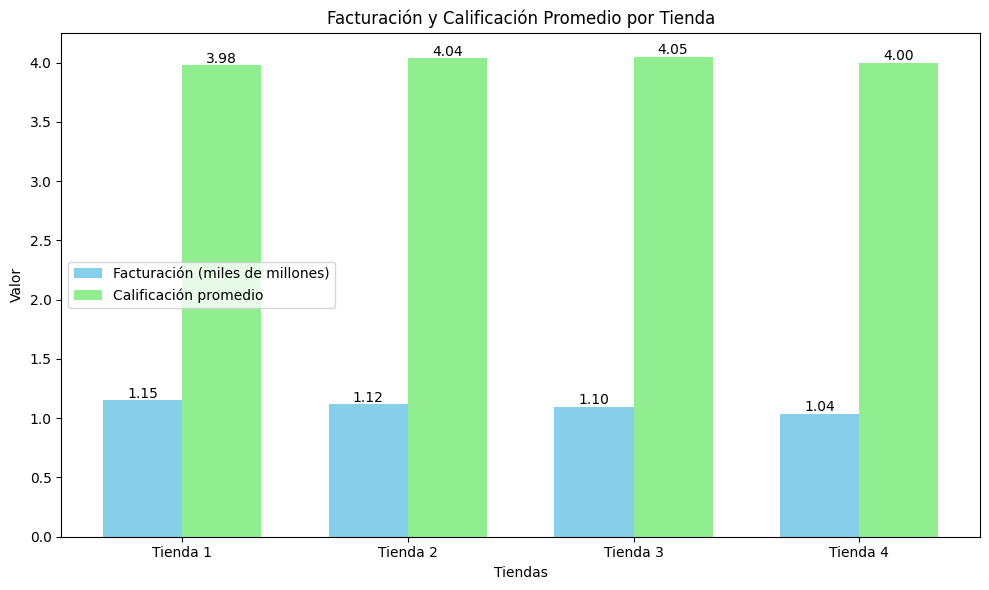

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
facturacion = [1150880400, 1116343500, 1098019600, 1038375700]
calificaciones = [3.98, 4.04, 4.05, 4.00]

# Normalizamos la facturación para que sea comparable visualmente con calificaciones
facturacion_normalizada = [f / 1e9 for f in facturacion]  # lo llevamos a miles de millones

# Posiciones para las barras
x = np.arange(len(tiendas))
ancho = 0.35  # ancho de las barras

# Creamos gráfico
plt.figure(figsize=(10, 6))
plt.bar(x - ancho/2, facturacion_normalizada, width=ancho, label='Facturación (miles de millones)', color='skyblue')
plt.bar(x + ancho/2, calificaciones, width=ancho, label='Calificación promedio', color='lightgreen')

# Títulos y etiquetas
plt.title('Facturación y Calificación Promedio por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Valor')
plt.xticks(x, tiendas)
plt.legend()

# Mostramos los valores sobre las barras
for i in range(len(tiendas)):
    plt.text(x[i] - ancho/2, facturacion_normalizada[i] + 0.02, f"{facturacion_normalizada[i]:.2f}", ha='center')
    plt.text(x[i] + ancho/2, calificaciones[i] + 0.02, f"{calificaciones[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

In [ ]:
# La cantidad de veces que se ha vendido un producto segun su categoria:

# para la tienda 1:
venta_categoria_t1 = tienda['Categoría del Producto'].value_counts()

# para la tienda 2:
venta_categoria_t2 = tienda2['Categoría del Producto'].value_counts()

# para la tienda 3:
venta_categoria_t3 = tienda3['Categoría del Producto'].value_counts()

# para la tienda 4:
venta_categoria_t4 = tienda4['Categoría del Producto'].value_counts()

print("Cantidad de veces que se vendió cada categoría:")
print("Tienda 1:")
print(venta_categoria_t1)
print("Tienda 2:")
print(venta_categoria_t2)
print("Tienda 3:")
print(venta_categoria_t3)
print("Tienda 4:")
print(venta_categoria_t4)

Cantidad de veces que se vendió cada categoría:
Tienda 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64
Tienda 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64
Tienda 3:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64
Tienda 4:
Categoría del Product

In [ ]:
# Los resultados los colocamos en diccionarios para una mejor manipulación de los datos
ventas_por_categoria ={
    'cat_tienda' : {
        'Muebles' : 465,
        'Electrónicos' : 448,
        'Juguetes' : 324,
        'Electrodomésticos' : 312,
        'Deportes y diversión' : 284,
        'Instrumentos musicales' : 182,
        'Libros' : 173,
        'Artículos para el hogar' : 171
      },

    'cat_tienda2' : {
        'Muebles' : 442,
        'Electrónicos' : 422,
        'Juguetes' : 313,
        'Electrodomésticos' : 305,
        'Deportes y diversión' : 275,
        'Instrumentos musicales' : 224,
        'Libros' : 197,
        'Artículos para el hogar' :181
      },
    'cat_tienda3' : {
        'Muebles': 499,
        'Electrónicos': 451,
        'Juguetes' : 315,
        'Electrodomésticos' : 278,
        'Deportes y diversión' : 277,
        'Libros' : 185,
        'Instrumentos musicales' : 177,
        'Artículos para el hogar' : 177
    },
    'cat_tienda4': {
      'Muebles' : 480,
      'Electrónicos' : 451,
      'Juguetes' : 338,
      'Deportes y diversión': 277,
      'Electrodomésticos' : 254,
      'Artículos para el hogar' : 201,
      'Libros' : 187,
      'Instrumentos musicales' : 170
    }
}


In [ ]:
# Recorremos cada tienda en el diccionario
print("Producto más vendido por tienda:\n")

for tienda in ventas_por_categoria:
    categorias = ventas_por_categoria[tienda]  # accedemos a las categorías y sus ventas

    producto_mas_vendido = None
    cantidad_maxima = None

    # Buscamos el producto con la mayor cantidad de ventas
    for producto in categorias:
        cantidad = categorias[producto]

        if cantidad_maxima is None or cantidad > cantidad_maxima:
            cantidad_maxima = cantidad
            producto_mas_vendido = producto

    # Mostramos el resultado para la tienda actual
    print(f"{tienda}: {producto_mas_vendido} con {cantidad_maxima} ventas")


Producto más vendido por tienda:

cat_tienda: Muebles con 465 ventas
cat_tienda2: Muebles con 442 ventas
cat_tienda3: Muebles con 499 ventas
cat_tienda4: Muebles con 480 ventas


In [ ]:
print("Producto menos vendido por tienda:\n")

for tienda in ventas_por_categoria:
    categorias = ventas_por_categoria[tienda]  # Obtenemos los productos y sus ventas

    producto_menos_vendido = None
    cantidad_minima = None

    for producto in categorias:
        cantidad = categorias[producto]

        if cantidad_minima is None or cantidad < cantidad_minima:
            cantidad_minima = cantidad
            producto_menos_vendido = producto

    print(f"{tienda}: {producto_menos_vendido} con {cantidad_minima} ventas")

Producto menos vendido por tienda:

cat_tienda: Artículos para el hogar con 171 ventas
cat_tienda2: Artículos para el hogar con 181 ventas
cat_tienda3: Instrumentos musicales con 177 ventas
cat_tienda4: Instrumentos musicales con 170 ventas


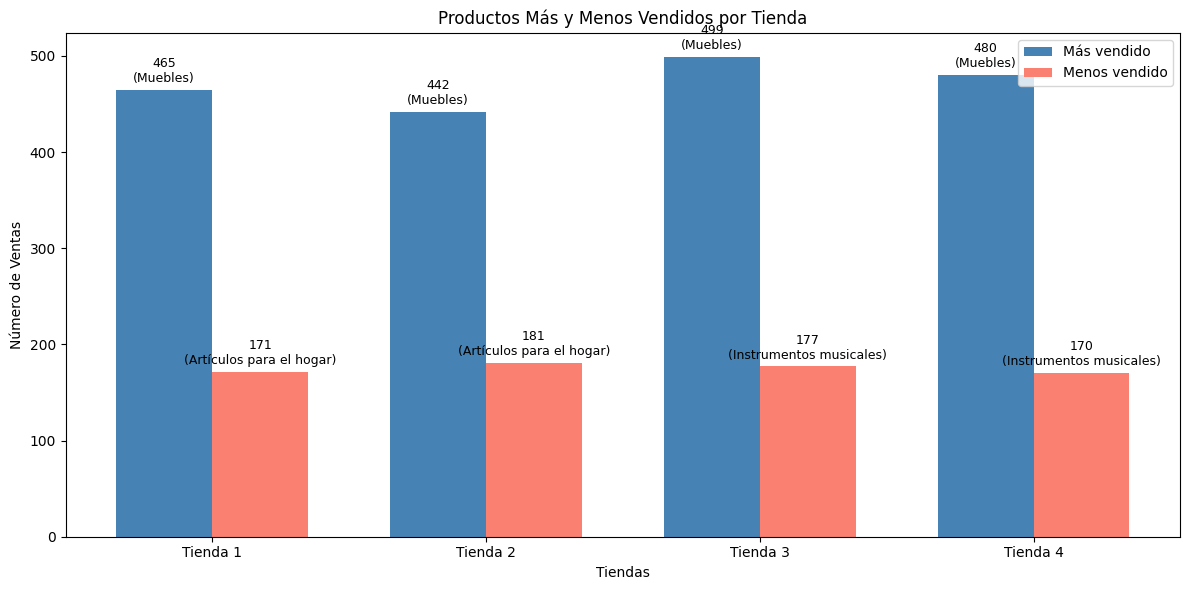

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las tiendas
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Ventas del producto más vendido
ventas_mas_vendido = [465, 442, 499, 480]
categorias_mas_vendido = ['Muebles', 'Muebles', 'Muebles', 'Muebles']

# Ventas del producto menos vendido
ventas_menos_vendido = [171, 181, 177, 170]
categorias_menos_vendido = ['Artículos para el hogar', 'Artículos para el hogar', 'Instrumentos musicales', 'Instrumentos musicales']

# Posiciones para las barras
x = np.arange(len(tiendas))
ancho = 0.35

# Crear el gráfico
plt.figure(figsize=(12, 6))
barras1 = plt.bar(x - ancho/2, ventas_mas_vendido, width=ancho, label='Más vendido', color='steelblue')
barras2 = plt.bar(x + ancho/2, ventas_menos_vendido, width=ancho, label='Menos vendido', color='salmon')

# Títulos y etiquetas
plt.title('Productos Más y Menos Vendidos por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Número de Ventas')
plt.xticks(x, tiendas)
plt.legend()

# Agregar valores y nombres de categorías sobre las barras
for i in range(len(tiendas)):
    plt.text(x[i] - ancho/2, ventas_mas_vendido[i] + 5, f"{ventas_mas_vendido[i]}\n({categorias_mas_vendido[i]})",
             ha='center', va='bottom', fontsize=9)
    plt.text(x[i] + ancho/2, ventas_menos_vendido[i] + 5, f"{ventas_menos_vendido[i]}\n({categorias_menos_vendido[i]})",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# 5. Envío promedio por tienda

In [ ]:
import pandas as pd

# Cargar los datos desde los CSV (ya lo has hecho)
tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

# Paso 1: Agregar la columna 'Tienda' manualmente a cada DataFrame
tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# Paso 2: Unir todos los DataFrames en un solo DataFrame
todas_las_tiendas = pd.concat([tienda, tienda2, tienda3, tienda4])

# Paso 3: Crear un diccionario para agrupar los costos de envío por tienda
grupos = {}

for venta in todas_las_tiendas.to_dict(orient='records'):
    tienda = venta["Tienda"]  # Ahora sabemos que cada venta tiene la columna 'Tienda'
    costo_envio = venta["Costo de envío"]  # Asegúrate de que esta es la columna correcta para el costo de envío

    if tienda not in grupos:
        grupos[tienda] = []

    grupos[tienda].append(costo_envio)

# Paso 4: Calcular el promedio del costo de envío por tienda
promedios_envio = {}

for tienda, costos in grupos.items():
    promedio = sum(costos) / len(costos)
    promedios_envio[tienda] = round(promedio, 2)

# Paso 5: Mostrar los resultados
for tienda, promedio in promedios_envio.items():
    print(f"{tienda}: ${promedio}")


Tienda 1: $26018.61
Tienda 2: $25216.24
Tienda 3: $24805.68
Tienda 4: $23459.46


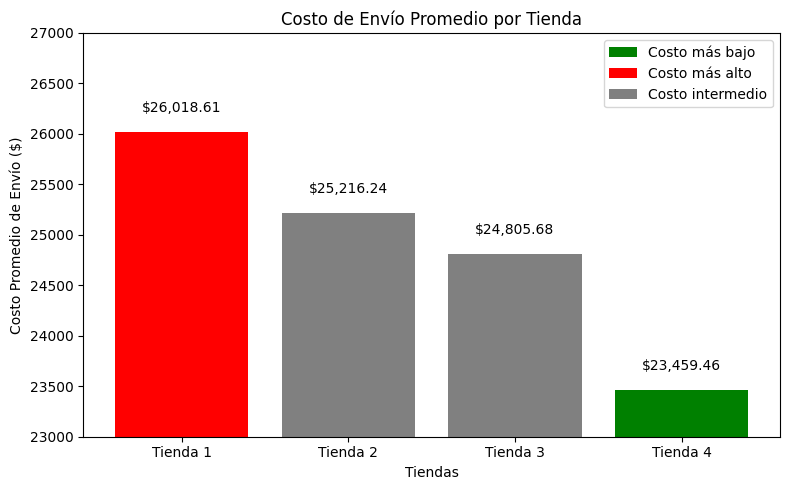

In [10]:
import matplotlib.pyplot as plt

# Datos
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
costos_envio = [26018.61, 25216.24, 24805.68, 23459.46]

# Determinar índices del costo más bajo y más alto
indice_min = costos_envio.index(min(costos_envio))
indice_max = costos_envio.index(max(costos_envio))

# Asignar colores según el valor
colores = []
for i in range(len(costos_envio)):
    if i == indice_min:
        colores.append('green')  # más barato
    elif i == indice_max:
        colores.append('red')    # más caro
    else:
        colores.append('gray')   # neutro

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.bar(tiendas, costos_envio, color=colores)

# Títulos y etiquetas
plt.title('Costo de Envío Promedio por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Costo Promedio de Envío ($)')
plt.ylim(23000, 27000)

# Mostrar valores sobre cada barra
for i, valor in enumerate(costos_envio):
    plt.text(i, valor + 200, f"${valor:,.2f}", ha='center')

# Leyenda personalizada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Costo más bajo'),
    Patch(facecolor='red', label='Costo más alto'),
    Patch(facecolor='gray', label='Costo intermedio')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


# Informe Final: Recomendación de Tienda para el Sr. Juan

## Introducción

Este informe tiene como objetivo analizar el desempeño de cuatro tiendas distintas en términos de ingresos, calificaciones de clientes, productos más y menos vendidos, ventas por categoría y costos de envío promedio. El propósito final es identificar cuál de estas tiendas debería ser vendida, basándonos en un análisis de datos cuantitativos respaldado por visualizaciones gráficas.

---

## Desarrollo del Análisis

### 1. Los Ingresos Totales de las Tiendas

La facturación total de cada tienda es la siguiente:

- **Tienda 1**: $1,150,880,400.00  
- **Tienda 2**: $1,116,343,500.00  
- **Tienda 3**: $1,098,019,600.00  
- **Tienda 4**: $1,038,375,700.00  

*Gráfico de barras muestra que Tienda 1 tiene la facturación más alta, mientras que Tienda 4 presenta la más baja.*

---

### 2. Las Categorías de Productos Más y Menos Vendidas

A continuación se muestra un resumen de las ventas por categoría en cada tienda:

#### **Tienda 1**:
- **Muebles**: 465 ventas
- **Electrónicos**: 448 ventas
- **Juguetes**: 324 ventas
- **Electrodomésticos**: 312 ventas
- **Deportes y diversión**: 284 ventas
- **Instrumentos musicales**: 182 ventas
- **Libros**: 173 ventas
- **Artículos para el hogar**: 171 ventas

#### **Tienda 2**:
- **Muebles**: 442 ventas
- **Electrónicos**: 422 ventas
- **Juguetes**: 313 ventas
- **Electrodomésticos**: 305 ventas
- **Deportes y diversión**: 275 ventas
- **Instrumentos musicales**: 224 ventas
- **Libros**: 197 ventas
- **Artículos para el hogar**: 181 ventas

#### **Tienda 3**:
- **Muebles**: 499 ventas
- **Electrónicos**: 451 ventas
- **Juguetes**: 315 ventas
- **Electrodomésticos**: 278 ventas
- **Deportes y diversión**: 277 ventas
- **Libros**: 185 ventas
- **Artículos para el hogar**: 177 ventas
- **Instrumentos musicales**: 177 ventas

#### **Tienda 4**:
- **Muebles**: 480 ventas
- **Electrónicos**: 451 ventas
- **Juguetes**: 338 ventas
- **Deportes y diversión**: 277 ventas
- **Electrodomésticos**: 254 ventas
- **Artículos para el hogar**: 201 ventas
- **Libros**: 187 ventas
- **Instrumentos musicales**: 170 ventas

*Gráfico de barras muestra la distribución de ventas por categoría para cada tienda, permitiendo una comparación visual de la importancia de cada categoría por tienda.*

---

### 3. Las Calificaciones Promedio de los Clientes por Tienda

Las calificaciones promedio reflejan la satisfacción del cliente:

- **Tienda 1**: 3.98  
- **Tienda 2**: 4.04  
- **Tienda 3**: 4.05  
- **Tienda 4**: 4.00  

*El gráfico destaca que Tienda 3 lidera en satisfacción de clientes, seguida por Tienda 2. Tienda 1 tiene la calificación más baja, lo cual podría ser una desventaja.*

---

### 4. Los Productos Más y Menos Vendidos

#### Productos más vendidos (todas las tiendas):
- **Categoría: Muebles**
  - Tienda 1: 465 ventas
  - Tienda 2: 442 ventas
  - Tienda 3: 499 ventas
  - Tienda 4: 480 ventas

#### Productos menos vendidos:
- Tienda 1 y 2: **Artículos para el hogar** (171 y 181 ventas)
- Tienda 3 y 4: **Instrumentos musicales** (177 y 170 ventas)

*El gráfico permite comparar de manera visual los productos más vendidos en cada tienda, lo que muestra que los muebles son la categoría dominante en todas las tiendas.*

---

### 5. El Costo de Envío Promedio para Cada Tienda

- **Tienda 1**: $26,018.61  
- **Tienda 2**: $25,216.24  
- **Tienda 3**: $24,805.68  
- **Tienda 4**: $23,459.46  

*El gráfico resalta que Tienda 4 tiene el costo de envío más bajo, mientras que Tienda 1 tiene el más alto, lo cual es relevante para la logística y costos operativos.*

---

## Conclusión y Recomendación

Tras analizar los ingresos, la satisfacción del cliente, las categorías de productos más y menos vendidos, y el costo de envío, se concluye que:

- **Tienda 1** lidera en ingresos, pero tiene la peor calificación de cliente y el costo de envío más alto, lo cual podría ser una desventaja para los clientes sensibles al costo.
- **Tienda 2** y **Tienda 3** logran un buen equilibrio entre facturación, calificaciones y costos de envío razonables. Sin embargo, Tienda 3 destaca con la mejor calificación promedio.
- **Tienda 4**, aunque tiene el costo de envío más bajo, presenta los ingresos más bajos, lo que puede limitar el alcance y la base de clientes.

### Recomendación final:
**La Tienda 4 debería ser vendida**. A pesar de tener el costo de envío más bajo, su volumen de ingresos es el más bajo entre todas las tiendas. Esto sugiere que, en términos de rentabilidad y potencial de crecimiento, Tienda 4 no sería la opción más viable a largo plazo para el Sr. Juan. En cambio, una tienda con mayores ingresos y un balance más positivo, como Tienda 3, debería ser la principal candidata para mantener o expandir su actividad.

---
